In [1]:
import touchsim as ts # import touchsim package
from touchsim.plotting import plot # import in-built plotting function
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
trace = np.genfromtxt('LH_thumb_stimulus_short.csv',delimiter=',') * 1.5

grid = ts.shape_bar(height=5., width=7.5, pins_per_mm=0.4)

s = ts.stim_indent_shape(grid, trace, fs=1000., pin_radius=0.5)

(0.0, 1.0)

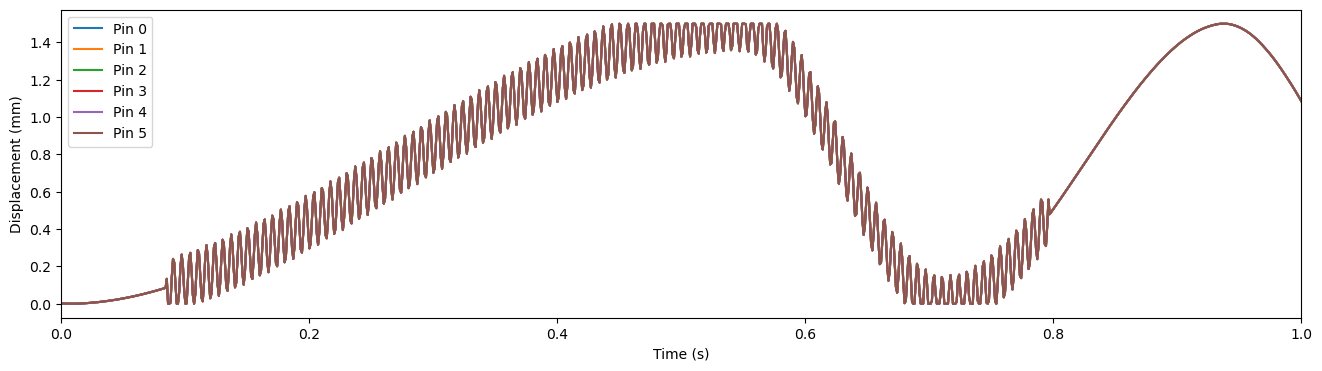

In [3]:
plt.figure(figsize=(16,4))
plot(s)
plt.xlim((0,1))

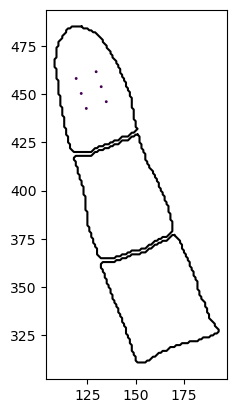

In [4]:
plot(region='D2')
plot(s,spatial=True)

In [5]:
print(s)

Stimulus with 6 pins and 660.001 s total duration.


# SA1

In [6]:
aSA = ts.affpop_hand(affclass='SA1', region='D2d')
rSA = aSA.response(s)

In [7]:
print(rSA)

Response consisting of:
* AfferentPopulation with 283 afferent(s): 283 SA1, 0 RA, 0 PC.
* 1 stimuli with 660.001 s total duration.
* 477994 total spikes.


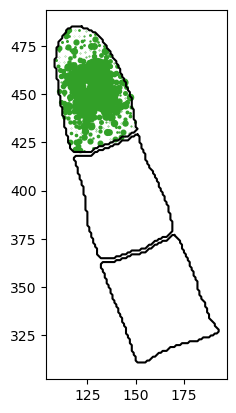

In [8]:
plot(region='D2')
plot(rSA,spatial=True,scaling_factor=0.01)

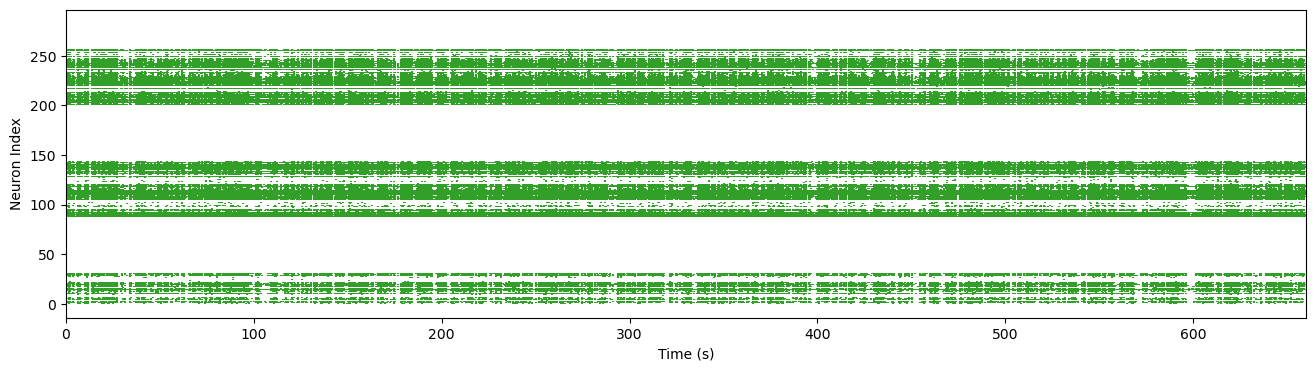

In [9]:
plt.figure(figsize=(16,4))
plot(rSA)

(0.0, 5.0)

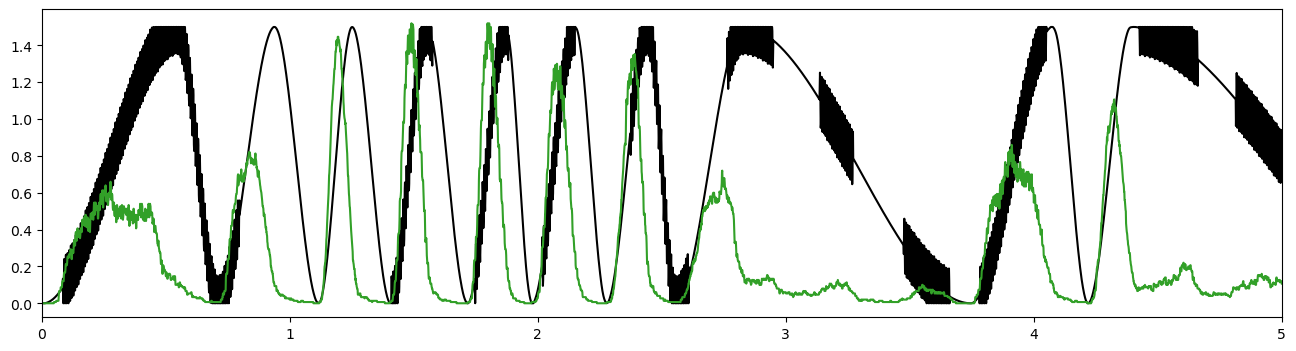

In [10]:
rfSA = np.convolve(rSA.psth(bin=1.).sum(axis=0),  np.ones((50,))/50,  mode='same')

plt.figure(figsize=(16,4))
plt.plot(np.linspace(0.0, 5.0, num=5000),trace[:5000], color='black')
plt.plot(np.linspace(0.0, 5.0, num=5000),rfSA[:5000]/3, color=ts.constants.affcol['SA1'])
plt.xlim((0,5))

In [11]:
np.corrcoef(rfSA, np.convolve(trace,  np.ones((50,))/50,  mode='same'))

array([[1.        , 0.18204473],
       [0.18204473, 1.        ]])

In [12]:
np.savetxt('SApop_1ms.csv', np.atleast_2d(rSA.psth(bin=1.).sum(axis=0)), delimiter=',', fmt='%1.1f')
np.savetxt('SApop_1ms_filt.csv', np.atleast_2d(rfSA), delimiter=',', fmt='%1.2f')

# FA

In [13]:
sFA = ts.stim_indent_shape(grid, trace[:50000], fs=1000., pin_radius=0.5)
aFA = ts.affpop_hand(affclass='RA', region='D2')
rFA = aFA.response(sFA)

In [14]:
print(rFA)

Response consisting of:
* AfferentPopulation with 945 afferent(s): 0 SA1, 945 RA, 0 PC.
* 1 stimuli with 50.0 s total duration.
* 267796 total spikes.


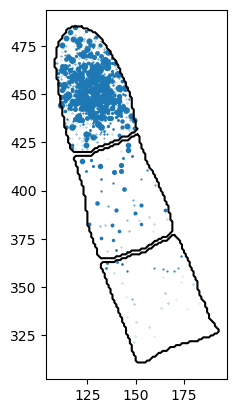

In [15]:
plot(region='D2')
plot(rFA,spatial=True,scaling_factor=0.01)

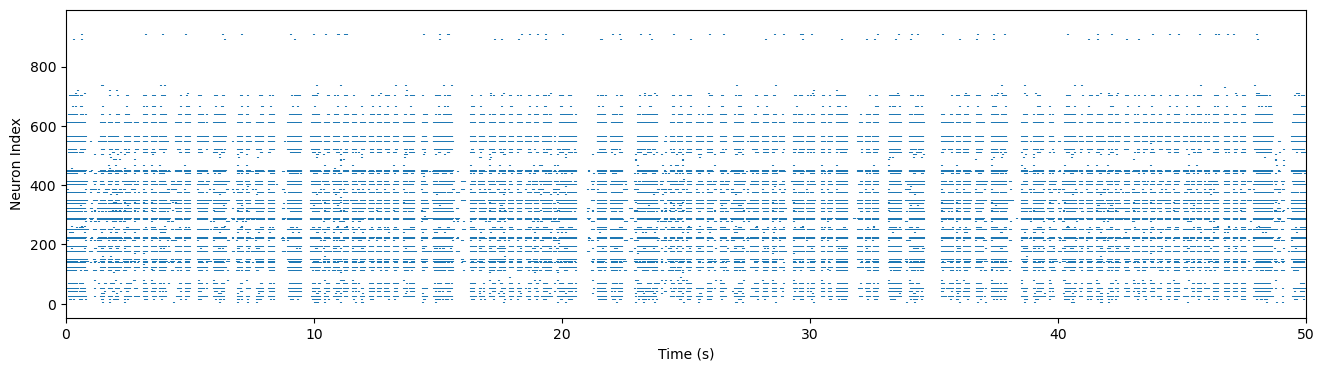

In [16]:
plt.figure(figsize=(16,4))
plot(rFA)

(0.0, 5.0)

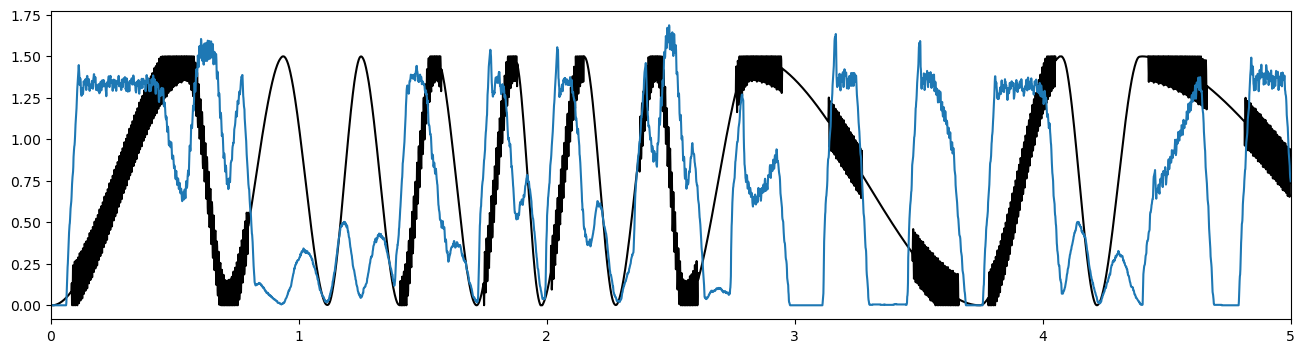

In [17]:
rfFA = np.convolve(rFA.psth(bin=1.).sum(axis=0),  np.ones((50,))/50,  mode='same')

plt.figure(figsize=(16,4))
plt.plot(np.linspace(0.0, 5.0, num=5000), trace[:5000], color='black')
plt.plot(np.linspace(0.0, 5.0, num=5000), rfFA[:5000]/8, color=ts.constants.affcol['RA'])
plt.xlim((0,5))

# PC

In [18]:
sPC = ts.stim_indent_shape(grid, trace[:50000], fs=1000., pin_radius=0.5)
aPC = ts.affpop_hand(affclass='PC')
rPC = aPC.response(sPC)

In [19]:
print(rPC)

Response consisting of:
* AfferentPopulation with 1917 afferent(s): 0 SA1, 0 RA, 1917 PC.
* 1 stimuli with 50.0 s total duration.
* 3746326 total spikes.


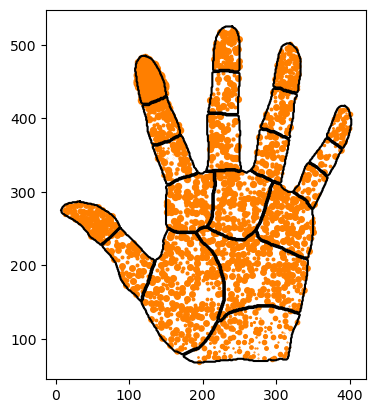

In [20]:
plot()
plot(rPC,spatial=True,scaling_factor=0.005)

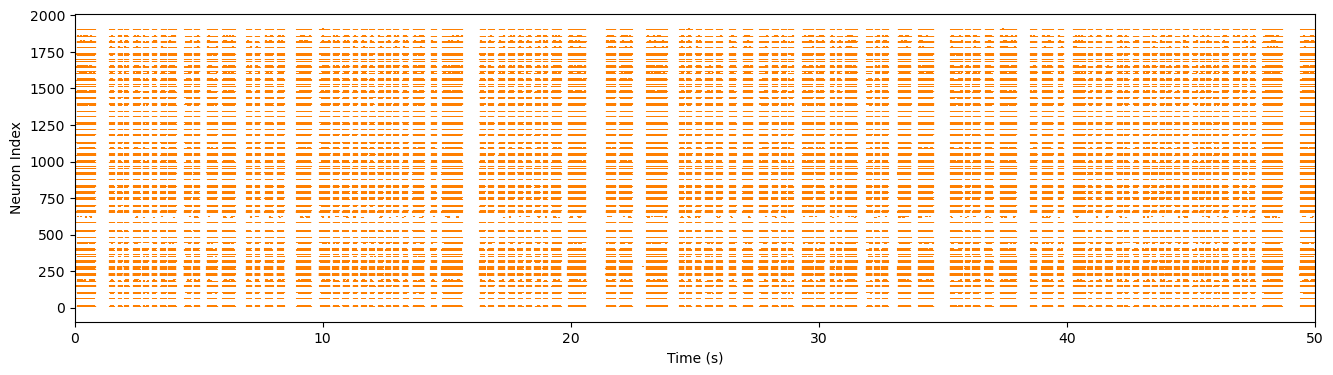

In [21]:
plt.figure(figsize=(16,4))
plot(rPC)

(0.0, 5.0)

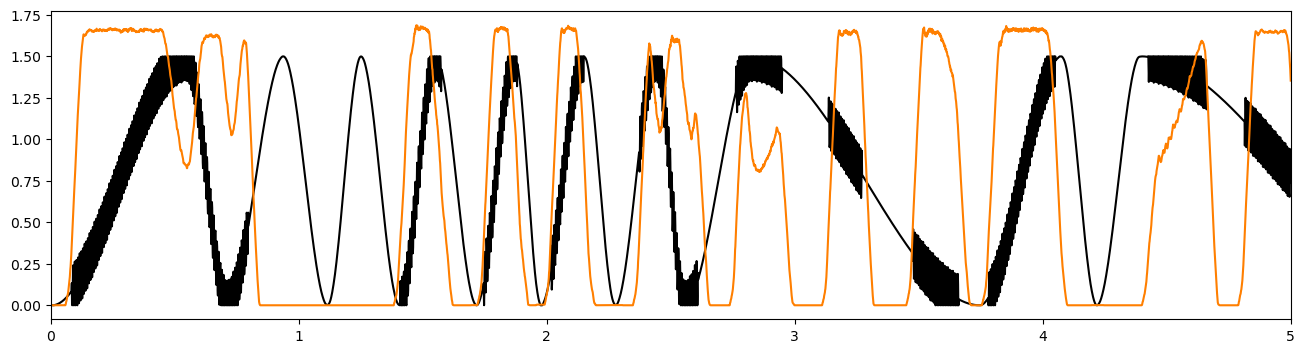

In [22]:
rfPC = np.convolve(rPC.psth(bin=1.).sum(axis=0),  np.ones((50,))/50,  mode='same')

plt.figure(figsize=(16,4))

plt.plot(np.linspace(0.0, 5.0, num=5000), trace[:5000], color='black')
plt.plot(np.linspace(0.0, 5.0, num=5000), rfPC[:5000]/100, color=ts.constants.affcol['PC'])
plt.xlim((0,5))

In [23]:
# SA-PC correlation
np.corrcoef(rfSA[:50000], rfPC)

array([[1.        , 0.18373977],
       [0.18373977, 1.        ]])

In [24]:
# SA-FA correlation
np.corrcoef(rfSA[:50000], rfFA)

array([[1.        , 0.22525728],
       [0.22525728, 1.        ]])

In [25]:
# FA-PC correlation
np.corrcoef(rfFA, rfPC)

array([[1.        , 0.93947247],
       [0.93947247, 1.        ]])